# Task 2 – Working with the lead-conversion table

**For:** the marketing team and the product owners of the verticals.

**The table:** `mart_lead_conversions`, built and tested in dbt (`dbt/models/marts/`). It has one row per lead,
with the contract attached if the lead converted. This notebook shows sample queries and charts that can be
built on it directly: plain SQL on one table, no joins.

**Before running:** `cd dbt && dbt build` creates the database file `dbt/lead_conversions.duckdb`.

### Good to know

- **One row per lead**, so counting rows counts leads.
- **`is_converted`** is true if the lead led to a signed contract, whatever its current status (active,
  cancelled or pending). A later cancellation does not undo the conversion.
- **`unknown`** in `vertical`, `source` or `region` means the value is missing or contradictory in the source
  data. The charts leave it out; the result tables keep it, so that they add up to all leads.
- **Contracts that cannot be assigned to a lead** (9 of 50) are not in the table: they cannot be credited to a
  channel, vertical or month.
- **Recent leads can still convert:** contracts are signed up to 40 days after the lead, so the latest month
  looks weaker than it will end up.
- **The data is checked on every dbt run**, e.g. one row per lead and no contract signed before its lead.

| column | meaning |
|---|---|
| `lead_id` | id of the lead |
| `lead_date`, `lead_month` | date the lead came in, and the first day of that month |
| `vertical` | comparison calculator: auto / haushalt / leben |
| `source` | marketing channel: google / newsletter / direct |
| `region` | Austrian federal state |
| `email` | e-mail address of the person |
| `is_converted` | true if the lead led to a signed contract |
| `conversion_id`, `signed_date` | id and signing date of the contract (empty if not converted) |
| `contract_status` | active / cancelled / pending |
| `premium` | annual net premium of the contract in EUR |
| `days_to_sign` | days from the lead to the signed contract |

In [1]:
import plotly.express as px

# Shared by the notebooks, see notebooks/common/
from common import bar_chart, configure_plotly, query

configure_plotly()

## 1. Overview: how many leads converted?

In [2]:
overview = query("""
    select
        count(*) as leads,
        count_if(is_converted) as conversions,
        count_if(contract_status = 'active') as active_contracts,
        round(100.0 * count_if(is_converted) / count(*), 1) as conversion_rate_pct,
        round(avg(days_to_sign), 1) as avg_days_to_sign
    from mart_lead_conversions
""")
overview

,leads,conversions,active_contracts,conversion_rate_pct,avg_days_to_sign
0,119,41,26,34.5,21.7


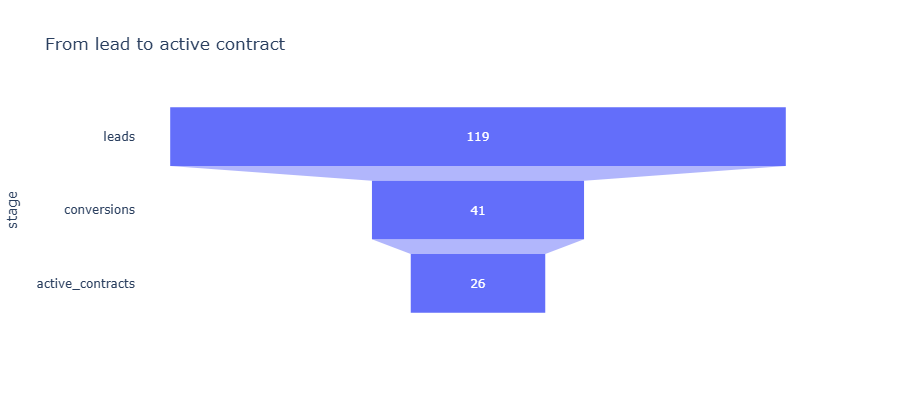

In [3]:
funnel = overview.melt(
    value_vars=["leads", "conversions", "active_contracts"],
    var_name="stage",
    value_name="count",
)
fig = px.funnel(funnel, x="count", y="stage", title="From lead to active contract")
fig.show()

**Reading:** 119 leads came in, 41 of them converted (34.5 %), and 26 of those contracts are active
today. A successful conversion takes 21.7 days on average. `avg(days_to_sign)` only averages the
converted leads, because `days_to_sign` is empty for the others.

## 2. How long does a successful conversion take?

Days from the lead to the signed contract, only for leads that converted:

In [4]:
speed = query("""
    select
        source as channel,
        count(*) as conversions,
        round(avg(days_to_sign), 1) as avg_days_to_sign,
        min(days_to_sign) as fastest_days,
        max(days_to_sign) as slowest_days
    from mart_lead_conversions
    where is_converted
    group by source
    order by avg_days_to_sign, channel
""")
speed

,channel,conversions,avg_days_to_sign,fastest_days,slowest_days
0,unknown,1,5.0,5,5
1,google,12,20.4,2,40
2,newsletter,16,22.6,2,39
3,direct,12,23.3,5,38


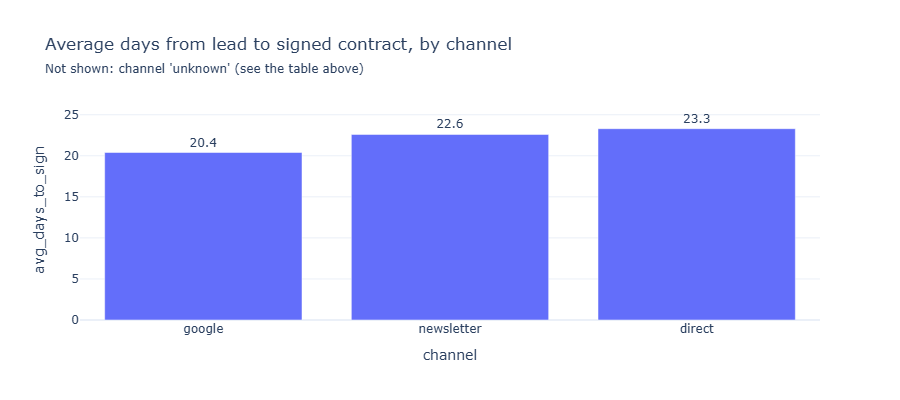

In [5]:
bar_chart(
    speed,
    x="channel",
    y="avg_days_to_sign",
    title="Average days from lead to signed contract, by channel",
)

**Reading:** a successful conversion takes about three weeks in every channel: 20.4 days for google,
23.3 for direct. The fastest contracts are signed after 2 days, the slowest after 40.

## 3. Which channel brings the most active premium?

Annual net premium of the contracts that are active today:

In [6]:
active_premium = query("""
    select
        source as channel,
        count_if(is_converted) as conversions,
        count_if(contract_status = 'active') as active_contracts,
        coalesce(sum(premium) filter (where contract_status = 'active'), 0) as active_premium
    from mart_lead_conversions
    group by source
    order by active_premium desc, channel
""")
active_premium

,channel,conversions,active_contracts,active_premium
0,newsletter,16,13,7630.45
1,direct,12,9,5828.03
2,google,12,4,3085.8
3,unknown,1,0,0.0


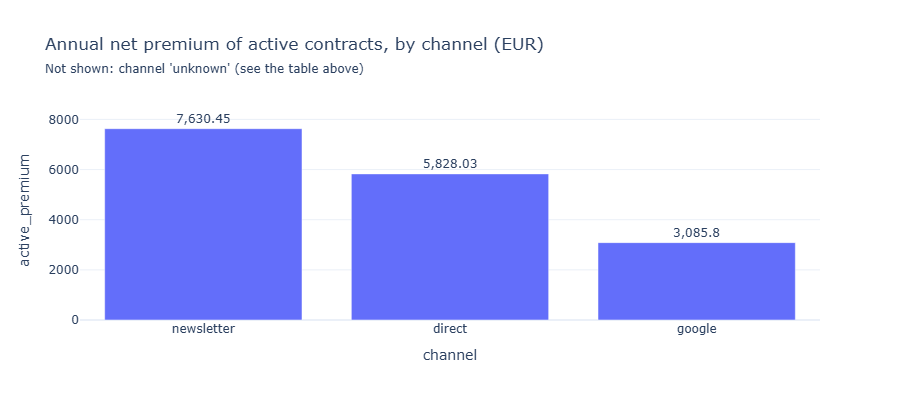

In [7]:
bar_chart(
    active_premium,
    x="channel",
    y="active_premium",
    title="Annual net premium of active contracts, by channel (EUR)",
)

**Reading:** newsletter leads bring the most active premium (7,630 EUR from 13 contracts). Google
leads bring the least (3,086 EUR), because only 4 of their 12 contracts are still active. One active
newsletter contract has no premium in the source data, so the newsletter sum is slightly too low.

## 4. Which leads have not converted?

The most recent leads without a contract, e.g. as a starting point for a follow-up:

In [8]:
query("""
    select lead_id, lead_date, vertical, source, email
    from mart_lead_conversions
    where not is_converted
    order by lead_date desc, lead_id
    limit 10
""")

,lead_id,lead_date,vertical,source,email
0,1050,2024-10-30,auto,direct,laura.pichler@gmx.at
1,1095,2024-10-30,haushalt,google,emma.leitner@outlook.com
2,1062,2024-10-25,haushalt,newsletter,jakob.wagner@outlook.com
3,1093,2024-10-25,auto,direct,emma.leitner@outlook.com
4,1009,2024-10-22,leben,google,anna.aigner@gmx.at
5,1069,2024-10-22,haushalt,newsletter,mia.berger@gmail.com
6,1010,2024-10-20,haushalt,google,emma.aigner@outlook.com
7,1064,2024-10-20,haushalt,direct,eva.hofer@aon.at
8,1044,2024-10-17,haushalt,direct,paul.berger@gmail.com
9,1045,2024-10-11,unknown,direct,tobias.gruber@hotmail.com


**Reading:** all ten came in October, so some of them may still convert. The same person can appear
more than once (emma.leitner@outlook.com has two leads), so a mailing should go out per e-mail
address, not per lead.